In [3]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Hurricane_Harvey_2017.m21fm - Result Files\elv_Stat_modified.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Surface elevation")

# Extract surface elevation and element coordinates
surface_elevation = data["Statistical maximum : Surface elevation"].to_numpy().flatten()
element_coordinates = ds.geometry.element_coordinates  # Element coordinates from DFSU geometry

# Convert element coordinates to a GeoDataFrame
element_gdf = gpd.GeoDataFrame(
    {"Surface_Elevation": surface_elevation},
    geometry=gpd.points_from_xy(element_coordinates[:, 0], element_coordinates[:, 1]),
    crs="EPSG:32614"  # Assuming your DFSU data is in UTM Zone 14N
)

# Load high water marks and land boundary shapefiles
hwm_path = r"D:\Phd Research\Data\Shape\usgs_harvey_high_water_marks.zip"
land_bnd_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(land_bnd_path)
hwm_data = gpd.read_file(hwm_path).to_crs("EPSG:32614")

# Clip high water marks to the land boundary
hwm_clipped = gpd.overlay(hwm_data, land_boundary, how='intersection')

# Spatial join to map surface elevation to high water mark points
hwm_clipped_with_elevation = gpd.sjoin(hwm_clipped, element_gdf, how="left", predicate="intersects")

# Save to a new shapefile (optional)
output_path = r"D:\Phd Research\Data\Shape\hwm_with_elevation.shp"
hwm_clipped_with_elevation.to_file(output_path)

# Display the result
print(hwm_clipped_with_elevation.head())


   hwm_id    hwm_label     site_no  site_id            flag_date  \
0   20765  0903_0900_1  TXARA20583    20583  9/3/2017 5:00:00 AM   
1   20766  0903_0900_2  TXARA20583    20583  9/3/2017 5:00:00 AM   
2   20768  0903_1000_1  TXARA20584    20584  9/3/2017 5:00:00 AM   
3   20769  0903_1000_2  TXARA20584    20584  9/3/2017 5:00:00 AM   
4   20770  0903_1000_3  TXARA20584    20584  9/3/2017 5:00:00 AM   

            survey_dat Type_Recla hwmTypeNam  hwm_type_i  \
0  9/6/2017 5:00:00 AM     debris     Debris           2   
1  9/5/2017 5:00:00 AM     debris     Debris           2   
2  9/5/2017 5:00:00 AM     debris     Debris           2   
3  9/5/2017 5:00:00 AM     debris     Debris           2   
4  9/5/2017 5:00:00 AM     debris     Debris           2   

                                            loc_desc  ...   surveyMemb  \
0  fence post near north end of bridge (upstream ...  ...  Don Hampton   
1             north end of bridge (downstream side).  ...  Don Hampton   
2       

C:\Users\sahad2\AppData\Local\Temp\ipykernel_35484\3902955713.py:37: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  hwm_clipped_with_elevation.to_file(output_path)
C:\Users\sahad2\AppData\Roaming\Python\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
C:\Users\sahad2\AppData\Roaming\Python\Python311\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Surface_Elevation' to 'Surface_El'
  ogr_write(


NameError: name 'ctx' is not defined

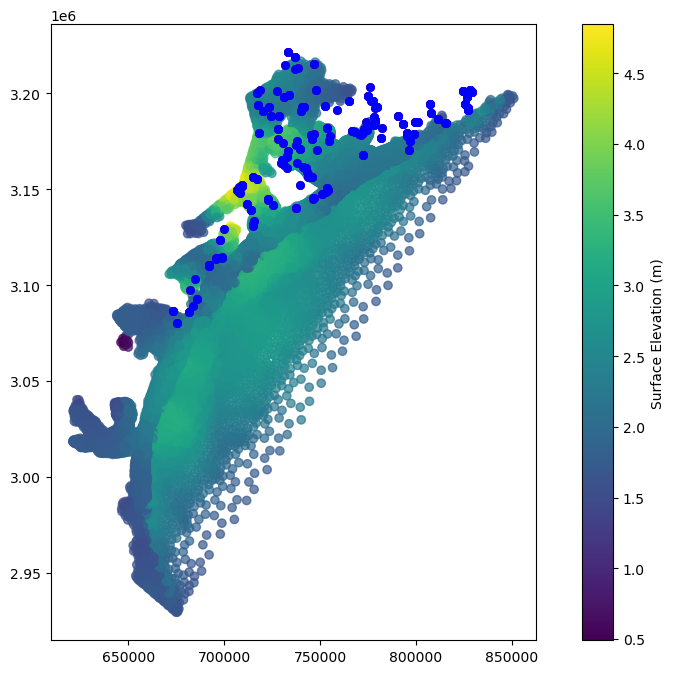

In [4]:

# Plot the surface elevation map
fig, ax = plt.subplots(figsize=(12, 8))

# Surface elevation GeoDataFrame
element_gdf.plot(
    column="Surface_Elevation",
    cmap="viridis",
    legend=True,
    legend_kwds={'label': "Surface Elevation (m)"},
    ax=ax,
    alpha=0.7
)

# Plot HWM clipped points without elevation (red dots)
hwm_clipped.plot(
    ax=ax,
    color="red",
    markersize=30,
    label="HWM Clipped"
)

# Plot HWM clipped with elevation (blue dots)
hwm_clipped_with_elevation.plot(
    ax=ax,
    color="blue",
    markersize=30,
    label="HWM Clipped with Elevation"
)

# Add basemap for context
ctx.add_basemap(ax, crs='EPSG:32614', source=ctx.providers.OpenStreetMap.Mapnik)

# Set axis labels and title
ax.set_title("Surface Elevation with HWM Points", fontsize=16)
ax.set_xlabel("Easting (m)", fontsize=12)
ax.set_ylabel("Northing (m)", fontsize=12)

# Add legend
ax.legend(loc="upper right", fontsize=10)

# Show plot
plt.tight_layout()
plt.show()


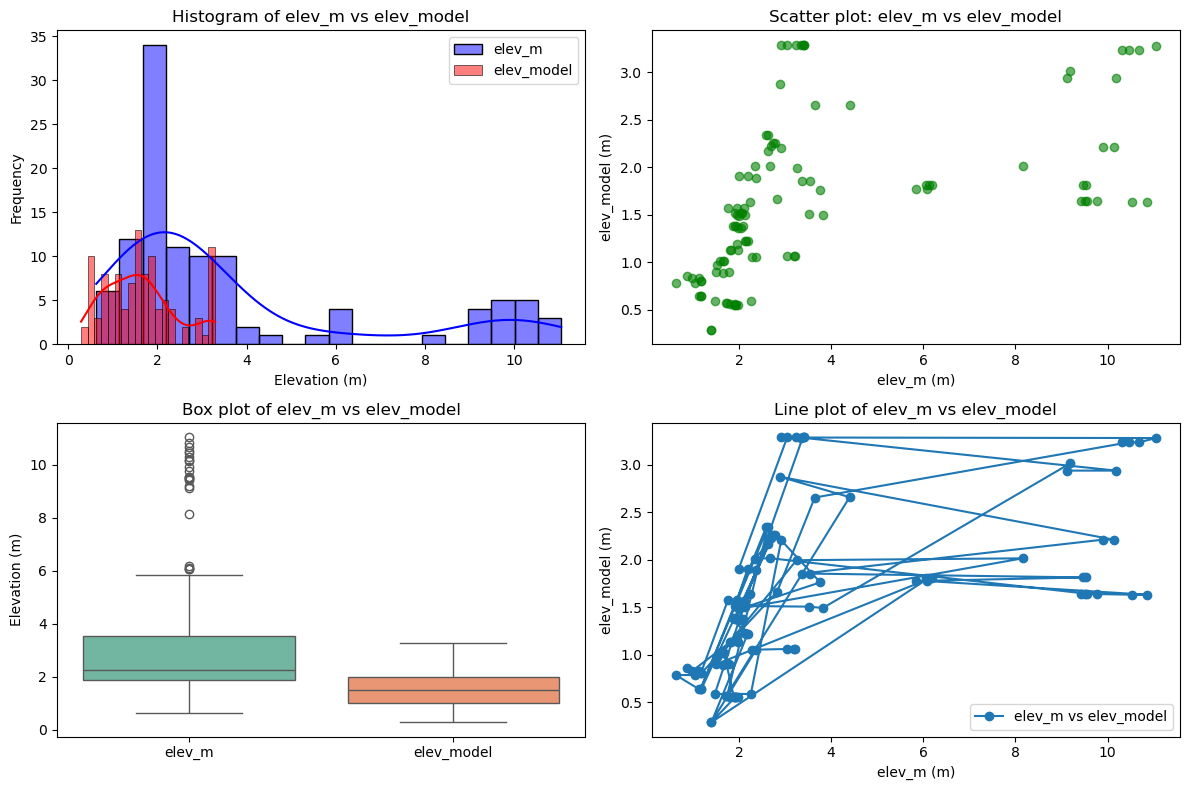

In [5]:
path = r"D:\Phd Research\Data\Shape\hwm_with_wo_nan.zip"
hwm_clipped = gpd.read_file(path)
# Filter rows where both 'elev_m' and 'elev_model' are not NaN
valid_data = hwm_clipped.dropna(subset=['elev_m', 'elev_model'])

# Plot comparisons
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# 1. Histogram for comparing the distributions of 'elev_m' and 'elev_model'
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, plot 1
sns.histplot(valid_data['elev_m'], color='blue', label='elev_m', kde=True, bins=20)
sns.histplot(valid_data['elev_model'], color='red', label='elev_model', kde=True, bins=20)
plt.title('Histogram of elev_m vs elev_model')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.legend()

# 2. Scatter plot to compare 'elev_m' vs 'elev_model'
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, plot 2
plt.scatter(valid_data['elev_m'], valid_data['elev_model'], alpha=0.6, c='green')
plt.title('Scatter plot: elev_m vs elev_model')
plt.xlabel('elev_m (m)')
plt.ylabel('elev_model (m)')

# 3. Box plot to compare the distributions of 'elev_m' and 'elev_model'
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, plot 3
sns.boxplot(data=valid_data[['elev_m', 'elev_model']], palette='Set2')
plt.title('Box plot of elev_m vs elev_model')
plt.ylabel('Elevation (m)')

# 4. Line plot for visualizing correspondence
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, plot 4
plt.plot(valid_data['elev_m'], valid_data['elev_model'], 'o-', label='elev_m vs elev_model')
plt.title('Line plot of elev_m vs elev_model')
plt.xlabel('elev_m (m)')
plt.ylabel('elev_model (m)')
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In [6]:
# Compute basic statistics
correlation = valid_data['elev_m'].corr(valid_data['elev_model'])
print(f"Correlation between elev_m and elev_model: {correlation}")

# Summary statistics
print(valid_data[['elev_m', 'elev_model']].describe())


Correlation between elev_m and elev_model: 0.5283271197564523
           elev_m  elev_model
count  109.000000  109.000000
mean     3.667138    1.626959
std      2.984237    0.821417
min      0.626974    0.286120
25%      1.888236    1.016829
50%      2.275637    1.520800
75%      3.542081    2.014852
max     11.052048    3.292820


In [5]:
# Save the updated GeoDataFrame
output_path = r"D:\Phd Research\Data\Shape\hwm_with_wo_nan.shp"
valid_data.to_file(output_path)

Original data size: (109, 53)
Filtered data size (after removing outliers): (86, 53)
     elev_m  elev_model
0  3.045866    1.060584
1  3.191256    1.060584
2  3.221736    1.060584
3  2.275637    1.051392
4  2.369820    1.051392


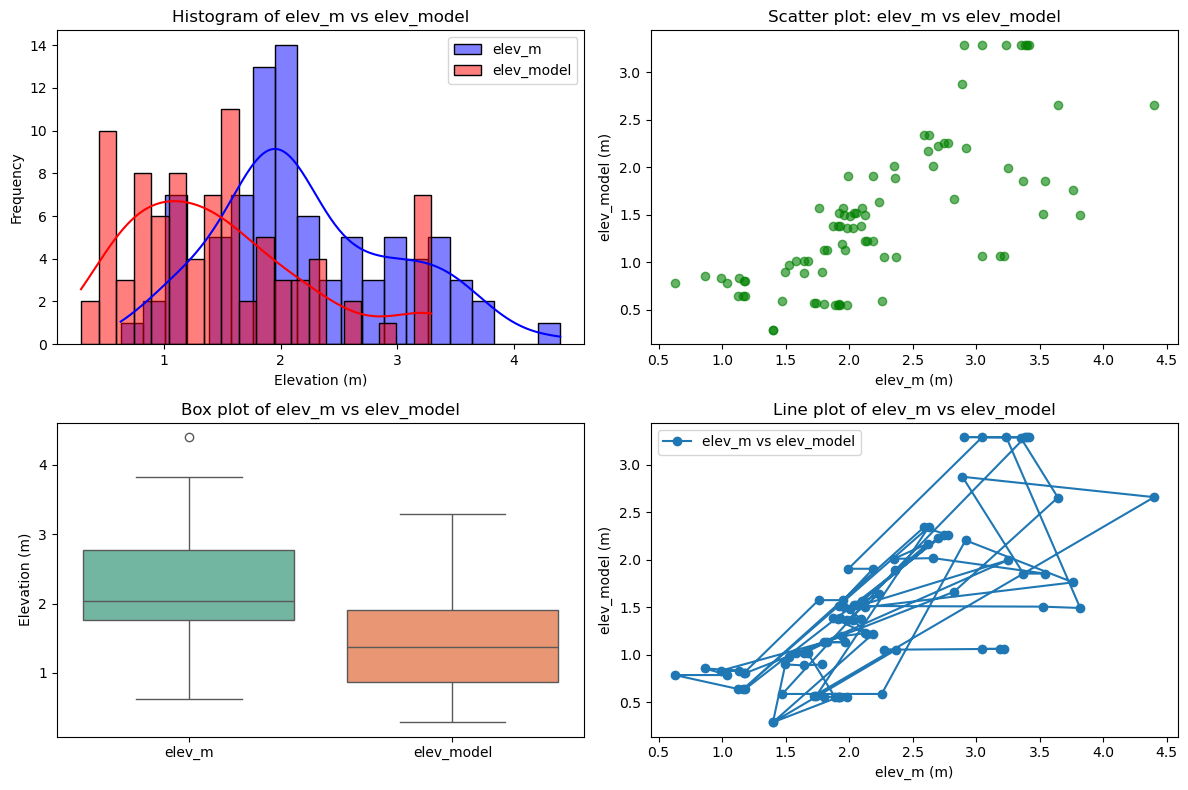

In [7]:
# Filter out rows where 'elev_m' is greater than 5
filtered_data = hwm_clipped[(hwm_clipped['elev_m'] <= 5) & hwm_clipped['elev_model'].notna()].copy()

# Confirm the shape of the filtered data
print(f"Original data size: {hwm_clipped.shape}")
print(f"Filtered data size (after removing outliers): {filtered_data.shape}")

# Check the first few rows
print(filtered_data[['elev_m', 'elev_model']].head())

# Proceed to draw the comparison plots
plt.figure(figsize=(12, 8))

# 1. Histogram for comparing the distributions of 'elev_m' and 'elev_model'
plt.subplot(2, 2, 1)
sns.histplot(filtered_data['elev_m'], color='blue', label='elev_m', kde=True, bins=20)
sns.histplot(filtered_data['elev_model'], color='red', label='elev_model', kde=True, bins=20)
plt.title('Histogram of elev_m vs elev_model')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.legend()

# 2. Scatter plot to compare 'elev_m' vs 'elev_model'
plt.subplot(2, 2, 2)
plt.scatter(filtered_data['elev_m'], filtered_data['elev_model'], alpha=0.6, c='green')
plt.title('Scatter plot: elev_m vs elev_model')
plt.xlabel('elev_m (m)')
plt.ylabel('elev_model (m)')

# 3. Box plot to compare the distributions of 'elev_m' and 'elev_model'
plt.subplot(2, 2, 3)
sns.boxplot(data=filtered_data[['elev_m', 'elev_model']], palette='Set2')
plt.title('Box plot of elev_m vs elev_model')
plt.ylabel('Elevation (m)')

# 4. Line plot for visualizing correspondence
plt.subplot(2, 2, 4)
plt.plot(filtered_data['elev_m'], filtered_data['elev_model'], 'o-', label='elev_m vs elev_model')
plt.title('Line plot of elev_m vs elev_model')
plt.xlabel('elev_m (m)')
plt.ylabel('elev_model (m)')
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In [7]:
# Compute basic statistics
correlation = filtered_data['elev_m'].corr(valid_data['elev_model'])
print(f"Correlation between elev_m and elev_model: {correlation}")

# Summary statistics
print(filtered_data[['elev_m', 'elev_model']].describe())

Correlation between elev_m and elev_model: 0.7252008919133354
          elev_m  elev_model
count  86.000000   86.000000
mean    2.228177    1.471723
std     0.780616    0.795926
min     0.626974    0.286120
25%     1.765402    0.862172
50%     2.035150    1.370436
75%     2.770784    1.901530
max     4.401312    3.292820


Statistics for the first 30 best-matched data points:
          elev_m  elev_model   abs_diff
count  30.000000   30.000000  30.000000
mean    2.179533    1.961312   0.274856
std     0.861865    0.942917   0.158230
min     0.626974    0.638441   0.010676
25%     1.321613    0.986874   0.133261
50%     2.269693    1.904907   0.283531
75%     2.854452    2.741295   0.402115
max     3.418027    3.292820   0.489452


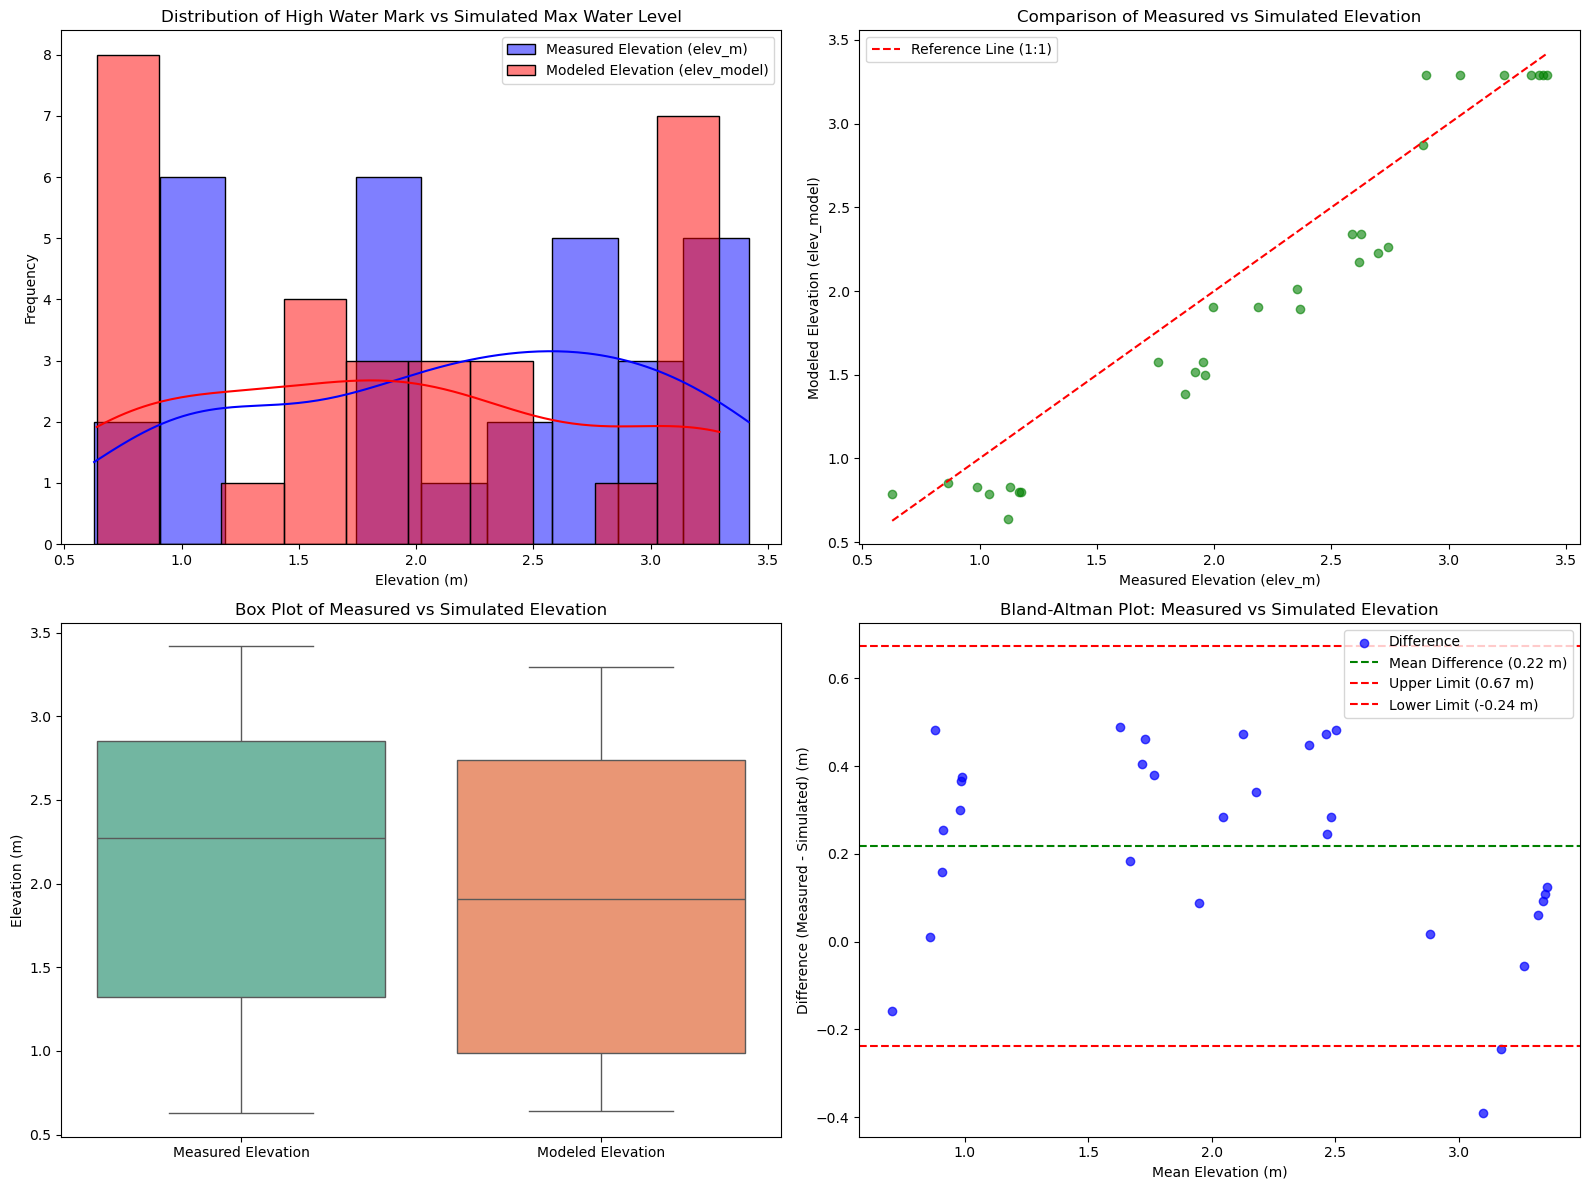

In [8]:
# Calculate the absolute difference between 'elev_m' and 'elev_model'
filtered_data['abs_diff'] = abs(filtered_data['elev_m'] - filtered_data['elev_model'])

# Sort the data by the smallest absolute difference
best_matches = filtered_data.sort_values(by='abs_diff').head(30).copy()

# Display basic statistics
print("Statistics for the first 30 best-matched data points:")
print(best_matches[['elev_m', 'elev_model', 'abs_diff']].describe())

# Plot the data
plt.figure(figsize=(16, 12))

# 1. Histogram for comparing distributions
plt.subplot(2, 2, 1)
sns.histplot(best_matches['elev_m'], color='blue', label='Measured Elevation (elev_m)', kde=True, bins=10)
sns.histplot(best_matches['elev_model'], color='red', label='Modeled Elevation (elev_model)', kde=True, bins=10)
plt.title('Distribution of High Water Mark vs Simulated Max Water Level')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.legend()

# 2. Scatter plot to compare 'elev_m' vs 'elev_model'
plt.subplot(2, 2, 2)
plt.scatter(best_matches['elev_m'], best_matches['elev_model'], alpha=0.6, c='green')
plt.plot([best_matches['elev_m'].min(), best_matches['elev_m'].max()],
         [best_matches['elev_m'].min(), best_matches['elev_m'].max()],
         color='red', linestyle='--', label='Reference Line (1:1)')
plt.title('Comparison of Measured vs Simulated Elevation')
plt.xlabel('Measured Elevation (elev_m)')
plt.ylabel('Modeled Elevation (elev_model)')
plt.legend()

# 3. Box plot to compare distributions
plt.subplot(2, 2, 3)
sns.boxplot(data=best_matches[['elev_m', 'elev_model']], palette='Set2')
plt.title('Box Plot of Measured vs Simulated Elevation')
plt.ylabel('Elevation (m)')
plt.xticks([0, 1], ['Measured Elevation', 'Modeled Elevation'])

# 4. Bland-Altman Plot
plt.subplot(2, 2, 4)
mean_elev = (best_matches['elev_m'] + best_matches['elev_model']) / 2
diff_elev = best_matches['elev_m'] - best_matches['elev_model']

# Calculate limits of agreement
mean_diff = diff_elev.mean()
std_diff = diff_elev.std()
upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# Scatter plot of differences
plt.scatter(mean_elev, diff_elev, color='blue', alpha=0.7, label='Difference')

# Add reference lines
plt.axhline(mean_diff, color='green', linestyle='--', label=f'Mean Difference ({mean_diff:.2f} m)')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Upper Limit ({upper_limit:.2f} m)')
plt.axhline(lower_limit, color='red', linestyle='--', label=f'Lower Limit ({lower_limit:.2f} m)')

plt.title('Bland-Altman Plot: Measured vs Simulated Elevation')
plt.xlabel('Mean Elevation (m)')
plt.ylabel('Difference (Measured - Simulated) (m)')
plt.legend()

# Adjust layout and show plots
plt.tight_layout()
plt.show()


In [9]:
# Compute basic statistics
correlation = best_matches['elev_m'].corr(valid_data['elev_model'])
print(f"Correlation between elev_m and elev_model: {correlation}")

# Summary statistics
print(best_matches[['elev_m', 'elev_model']].describe())

Correlation between elev_m and elev_model: 0.9708643540702998
          elev_m  elev_model
count  30.000000   30.000000
mean    2.179533    1.961312
std     0.861865    0.942917
min     0.626974    0.638441
25%     1.321613    0.986874
50%     2.269693    1.904907
75%     2.854452    2.741295
max     3.418027    3.292820


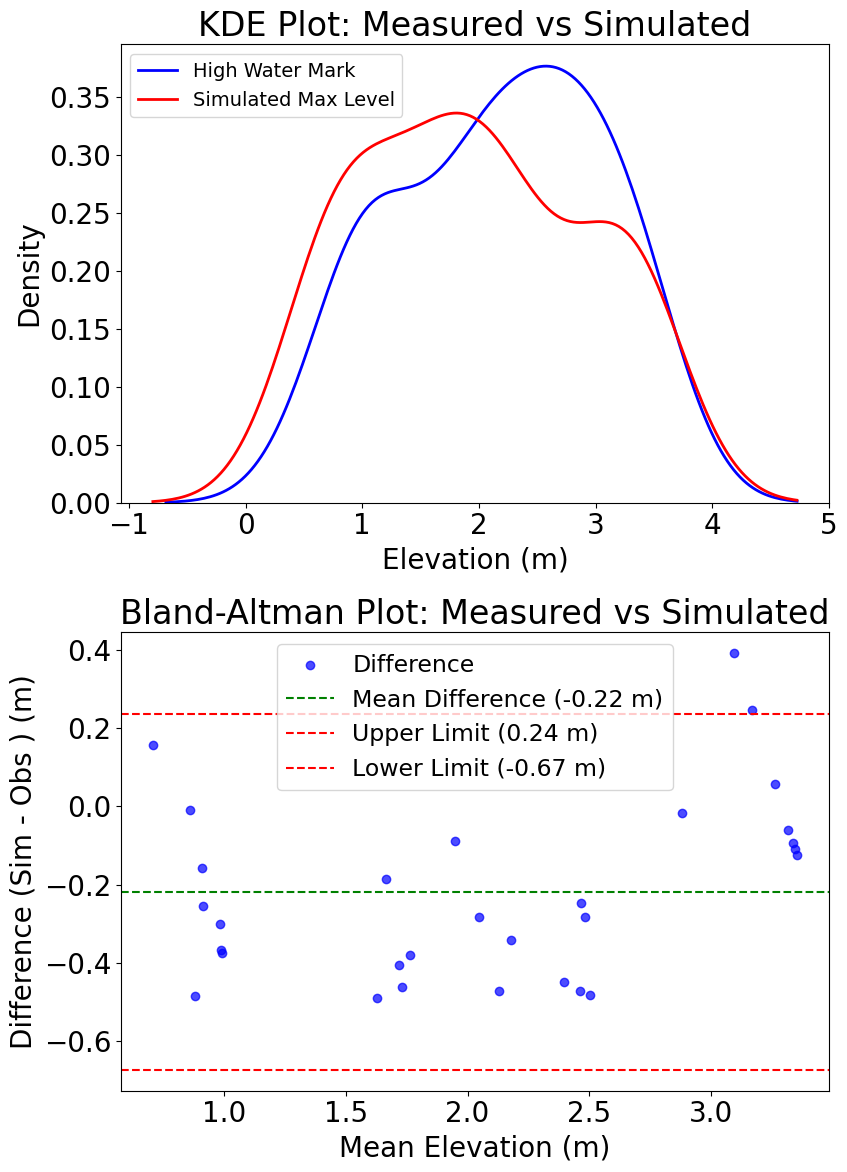

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global font size
plt.rcParams.update({'font.size': 16})  # You can adjust the size as needed

plt.rcParams['xtick.labelsize'] = 20   # Increase x-tick labels
plt.rcParams['ytick.labelsize'] = 20   # Increase y-tick labels
# Plot the data
plt.figure(figsize=(16,12))

# # 1. Histogram for comparing distributions
# plt.subplot(2, 2, 1)
# sns.histplot(best_matches['elev_m'], color='blue', label='High Water Mark', kde=True, bins=10)
# sns.histplot(best_matches['elev_model'], color='red', label='Simulated Max Level', kde=True, bins=10)
# plt.title('Distribution plot: Measured Vs Simulated', fontsize=18)
# plt.xlabel('Elevation (m)', fontsize=16)
# plt.ylabel('Frequency', fontsize=16)
# plt.legend(fontsize=14)
# Plot the KDE lines for both datasets
plt.subplot(2, 2, 2)
sns.kdeplot(best_matches['elev_m'], color='blue', label='High Water Mark', linewidth=2)
sns.kdeplot(best_matches['elev_model'], color='red', label='Simulated Max Level', linewidth=2)

# Add titles and labels
plt.title('KDE Plot: Measured vs Simulated', fontsize=24)
plt.xlabel('Elevation (m)', fontsize=20)
plt.ylabel('Density', fontsize=20)

# Add legend
plt.legend(fontsize=14)

# # 2. Scatter plot to compare 'elev_m' vs 'elev_model'
# plt.subplot(2, 2, 2)
# plt.scatter(best_matches['elev_m'], best_matches['elev_model'], alpha=0.6, c='green')
# plt.plot([best_matches['elev_m'].min(), best_matches['elev_m'].max()],
#          [best_matches['elev_m'].min(), best_matches['elev_m'].max()],
#          color='red', linestyle='--', label='Reference Line (1:1)')
# plt.title('Comparison Plot: Measured vs Simulated', fontsize=18)
# plt.xlabel('High Water Mark', fontsize=16)
# plt.ylabel('Simulated Max Level', fontsize=16)
# plt.legend(fontsize=14)

# 3. Box plot to compare distributions
# plt.subplot(2, 2, 3)
# sns.boxplot(data=best_matches[['elev_m', 'elev_model']], palette='Set2')
# plt.title('Box Plot: Measured vs Simulated', fontsize=20)
# plt.ylabel('Elevation (m)', fontsize=16)
# plt.xticks([0, 1], ['High Water Mark', 'Simulated Max Level'], fontsize=16)

# 4. Bland-Altman Plot
plt.subplot(2, 2, 4)
mean_elev = (best_matches['elev_m'] + best_matches['elev_model']) / 2
diff_elev =  best_matches['elev_model'] - best_matches['elev_m'] 

# Calculate limits of agreement
mean_diff = diff_elev.mean()
std_diff = diff_elev.std()
upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# Scatter plot of differences
plt.scatter(mean_elev, diff_elev, color='blue', alpha=0.7, label='Difference')

# Add reference lines
plt.axhline(mean_diff, color='green', linestyle='--', label=f'Mean Difference ({mean_diff:.2f} m)')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Upper Limit ({upper_limit:.2f} m)')
plt.axhline(lower_limit, color='red', linestyle='--', label=f'Lower Limit ({lower_limit:.2f} m)')

plt.title('Bland-Altman Plot: Measured vs Simulated', fontsize=24)
plt.xlabel('Mean Elevation (m)', fontsize=20)
plt.ylabel('Difference (Sim - Obs ) (m)', fontsize=20)
plt.legend(fontsize=17)

# Adjust layout and show plots
plt.tight_layout()
plt.show()


In [16]:
# Compute basic statistics
correlation = best_matches['elev_m'].corr(valid_data['elev_model'])
print(f"Correlation between elev_m and elev_model: {correlation}")

# Summary statistics
print(best_matches[['elev_m', 'elev_model']].describe())


Correlation between elev_m and elev_model: 0.9708643540702998
          elev_m  elev_model
count  30.000000   30.000000
mean    2.179533    1.961312
std     0.861865    0.942917
min     0.626974    0.638441
25%     1.321613    0.986874
50%     2.269693    1.904907
75%     2.854452    2.741295
max     3.418027    3.292820


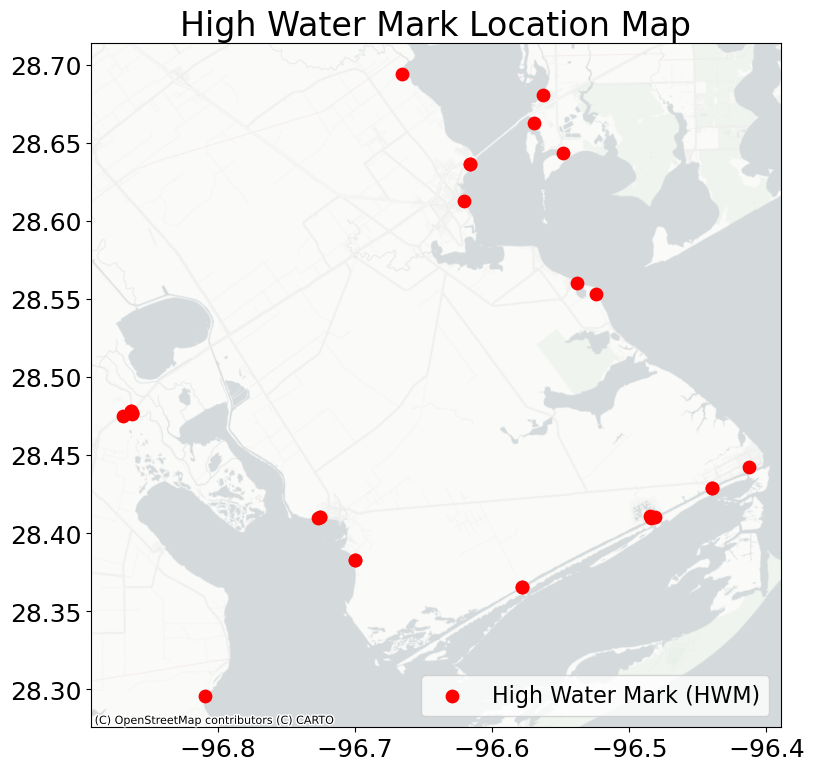

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx  # For adding basemap

# Select the top 30 matches based on a criterion (e.g., smallest absolute difference)
best_matches['abs_diff'] = abs(best_matches['elev_m'] - best_matches['elev_model'])
top_matches = best_matches.nsmallest(30, 'abs_diff')

# Create a GeoDataFrame for the points
geometry = [Point(xy) for xy in zip(top_matches['longitude'], top_matches['latitude'])]
gdf = gpd.GeoDataFrame(top_matches, geometry=geometry, crs="EPSG:4326")  # Assuming lat/lon

# Plot the points on a base map
fig, ax = plt.subplots(figsize=(12, 8))  # Slightly larger for better readability

# Plot the points
gdf.plot(ax=ax, color='red', label='High Water Mark (HWM)', marker='o', markersize=80)

# Add basemap
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels, zoom=12)


# Customize title and legend
plt.title('High Water Mark Location Map', fontsize=24)
plt.legend(fontsize=16, loc="lower right")

# Optional: Axis labels
# plt.xlabel('Longitude', fontsize=18)
# plt.ylabel('Latitude', fontsize=18)

# Increase axis tick label sizes
ax.tick_params(axis='both', which='major', labelsize=18)

# Improve layout and display
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Step 1: Ensure 'abs_diff' is computed
best_matches['abs_diff'] = abs(best_matches['elev_m'] - best_matches['elev_model'])

# Step 2: Select top 30 best-matched HWMs
top_matches = best_matches.nsmallest(30, 'abs_diff').copy()

# Step 3: Create geometry using longitude and latitude
geometry = [Point(xy) for xy in zip(top_matches['longitude'], top_matches['latitude'])]

# Step 4: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(top_matches, geometry=geometry, crs="EPSG:4326")  # WGS84 coordinate system

# Step 5: Export to shapefile
output_path = r"D:\Phd Research\Data\Shape\top30_hwm_best_match.shp"
gdf.to_file(output_path)

print(f"Shapefile successfully saved to: {output_path}")


Shapefile successfully saved to: D:\Phd Research\Data\Shape\top30_hwm_best_match.shp
